# 🔍 Práctica de comparación de LLMs · Modelo asignado: `mistralai/Mistral-7B-Instruct-v0.3`

**Modelo:** `mistralai/Mistral-7B-Instruct-v0.3` (~7,3B parámetros, mayo 2024)
**Tarea elegida por el grupo:** Clasificación de sentimiento de reseñas de producto (positiva / negativa / neutra).
**Estrategia:** comparar **3 prompts** × **5 repeticiones** sobre la misma reseña, con `temperature > 0`.

> ⚠️ **Requisitos de hardware:** Usa una GPU T4 o superior en Colab.
> Ir a `Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU`

---

### Identificación del modelo

| Campo | Valor |
|---|---|
| Nombre | `mistralai/Mistral-7B-Instruct-v0.3` |
| Familia | Mistral (Mistral AI) |
| Tamaño | ~7.300 millones de parámetros |
| Variante | *Instruction-tuned* (`-Instruct`) |
| Fecha de publicación | Mayo 2024 |
| Tensor type | BF16 |
| Ventana de contexto | 32.768 tokens |
| Licencia | Apache 2.0 |

**Motivo de elección:** referente consolidado en open-source. Con 7B parámetros ofrece una relación calidad/coste muy competitiva y sirve como punto de comparación intermedio entre el modelo ligero (Gemma 2 2B) y el modelo mediano (Phi-3 3.8B) del grupo. Su arquitectura con ventana de contexto larga permite seguir prompts estructurados con gran fidelidad.


---
## 📦 1. Instalación de dependencias


In [1]:
!pip install -q -U transformers accelerate bitsandbytes



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: C:\Users\juanb\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---
## 🔧 2. Verificación del entorno


In [2]:
import torch

print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU detectada: {torch.cuda.get_device_name(0)}")
    print(f"✅ VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    print("✅ Mac con MPS detectado.")
    DEVICE = "mps"
else:
    print("⚠️  No se detectó GPU. El modelo será MUY lento en CPU.")
    DEVICE = "cpu"


✅ PyTorch version: 2.9.1+cpu
✅ CUDA disponible: False
⚠️  No se detectó GPU. El modelo será MUY lento en CPU.


---
## 🤖 3. Carga del modelo Mistral-7B-Instruct-v0.3

Se carga con **cuantización 4-bit** (`bitsandbytes`) para que quepa en la GPU gratuita de Colab (~15 GB VRAM). Sin cuantización el modelo ocuparía ~14 GB en BF16.


In [3]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig

MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.3"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

print("✅ Pipeline listo.")
print(f"   Arquitectura : {pipe.model.config.model_type}")
print(f"   Device       : {pipe.model.device}")
print(f"   Dtype        : {pipe.model.dtype}")
print(f"   Parámetros   : {sum(p.numel() for p in pipe.model.parameters()) / 1e6:.1f} M")


C:\Users\juanb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\juanb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\juanb\.cache\huggingface\hub\models--mistralai--Mistral-7B-Instruct-v0.3. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/do

✅ Pipeline listo.
   Arquitectura : mistral
   Device       : cpu
   Dtype        : torch.bfloat16
   Parámetros   : 3758.4 M


---
## ⚙️ 4. Función de inferencia base

> Mistral-7B-Instruct admite el rol `system`, a diferencia de Gemma 2. Lo aprovechamos en el Prompt 2 para separar el contexto del sistema de la instrucción de usuario.

> Mantenemos `temperature=0.7`, `top_p=0.9`, `do_sample=True` como exige el enunciado (temperature > 0).


In [4]:
def generar_respuesta(prompt: str,
                     system: str = None,
                     temperature: float = 0.7,
                     top_p: float = 0.9,
                     max_new_tokens: int = 400) -> str:
    """
    Genera una respuesta de Mistral-7B-Instruct a partir de un prompt de usuario.
    Opcionalmente acepta un mensaje de sistema (role: system).
    Devuelve solo el texto del asistente (string).
    """
    mensajes = []
    if system:
        mensajes.append({"role": "system", "content": system})
    mensajes.append({"role": "user", "content": prompt})

    generation_args = {
        "max_new_tokens": max_new_tokens,
        "return_full_text": False,
        "do_sample": True,
        "temperature": temperature,
        "top_p": top_p,
    }

    output = pipe(mensajes, **generation_args)
    return output[0]["generated_text"].strip()


# Prueba rápida
test = generar_respuesta(
    "Saluda en una frase y di que estás listo para clasificar reseñas.",
    max_new_tokens=60,
)
print(test)


[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'top_p', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe

Hola! Estoy listo para clasificar reseñas. ¡Hazme saber qué reseñas necesitas que te ayude!


---
## 📝 5. Definición del problema y prompts

La reseña es la misma para los tres prompts. Lo único que cambia es la **estrategia de prompt engineering**.


In [5]:
RESENA = (
    "El producto llegó antes de lo esperado y el embalaje estaba perfecto. "
    "Sin embargo, después de usarlo tres días, dejó de funcionar correctamente. "
    "El servicio de atención al cliente no respondió a mis mensajes. "
    "Muy decepcionante."
)

ETIQUETA_GOLD = "negativa"  # Etiqueta de oro acordada por el grupo

# ---------- Prompt 1: BASE ----------
PROMPT_BASE = f'''Clasifica la siguiente reseña como positiva, negativa o neutra:
"{RESENA}"'''
SYSTEM_BASE = None

# ---------- Prompt 2: PLANTILLA CLARA ----------
# Mistral admite rol system -> separamos contexto de instrucción
SYSTEM_PLANTILLA = (
    "Eres un sistema de análisis de opiniones para una tienda online. "
    "La clasificación se usará para mejorar el servicio al cliente."
)
PROMPT_PLANTILLA = f'''Tarea: Clasifica la reseña de un producto como positiva, negativa o neutra.
Restricciones:
- Responde únicamente con una de estas etiquetas: positiva, negativa, neutra.
- Añade una justificación de máximo 2 frases.
- No uses información externa a la reseña.
Formato de salida:
Clasificación: [etiqueta]
Justificación: [máximo 2 frases]
Criterio de calidad: La clasificación debe reflejar el sentimiento predominante
del texto, no solo aspectos aislados.
Reseña: "{RESENA}"'''

# ---------- Prompt 3: RAZONAMIENTO Y CONTRASTE ----------
PROMPT_RAZONAMIENTO = f'''Analiza la siguiente reseña de producto paso a paso y determina su clasificación.
Reseña: "{RESENA}"
Sigue estos pasos:
1. Identifica los aspectos positivos mencionados en la reseña.
2. Identifica los aspectos negativos mencionados en la reseña.
3. Considera las tres posibles clasificaciones: positiva, negativa y neutra.
4. Compara el peso de los argumentos a favor de cada una.
5. Escribe una conclusión final justificada con la clasificación elegida.
Formato de respuesta:
Aspectos positivos: ...
Aspectos negativos: ...
Análisis de alternativas: ...
Conclusión y clasificación final: ...'''
SYSTEM_RAZONAMIENTO = None

PROMPTS = {
    "1_base":         {"prompt": PROMPT_BASE,         "system": SYSTEM_BASE},
    "2_plantilla":    {"prompt": PROMPT_PLANTILLA,    "system": SYSTEM_PLANTILLA},
    "3_razonamiento": {"prompt": PROMPT_RAZONAMIENTO, "system": SYSTEM_RAZONAMIENTO},
}

for nombre, p in PROMPTS.items():
    print(f"--- {nombre} ---")
    if p["system"]:
        print(f"[SYSTEM] {p['system'][:100]}...")
    print(p["prompt"][:200] + ("..." if len(p["prompt"]) > 200 else ""))
    print()


--- 1_base ---
Clasifica la siguiente reseña como positiva, negativa o neutra:
"El producto llegó antes de lo esperado y el embalaje estaba perfecto. Sin embargo, después de usarlo tres días, dejó de funcionar corre...

--- 2_plantilla ---
[SYSTEM] Eres un sistema de análisis de opiniones para una tienda online. La clasificación se usará para mejo...
Tarea: Clasifica la reseña de un producto como positiva, negativa o neutra.
Restricciones:
- Responde únicamente con una de estas etiquetas: positiva, negativa, neutra.
- Añade una justificación de má...

--- 3_razonamiento ---
Analiza la siguiente reseña de producto paso a paso y determina su clasificación.
Reseña: "El producto llegó antes de lo esperado y el embalaje estaba perfecto. Sin embargo, después de usarlo tres día...



---
## 🔬 6. Ejecución del experimento

5 repeticiones por prompt → 15 ejecuciones totales con `temperature=0.7`, `top_p=0.9`.

> Tiempo estimado en T4: ~3–5 minutos.


In [ ]:
import pandas as pd
import time

N_REPETICIONES = 5
TEMPERATURE = 0.7
TOP_P = 0.9

resultados = []
t0 = time.time()

for nombre_prompt, config in PROMPTS.items():
    for i in range(1, N_REPETICIONES + 1):
        print(f"[{nombre_prompt}] repetición {i}/{N_REPETICIONES} ...", end=" ", flush=True)
        ti = time.time()
        respuesta = generar_respuesta(
            config["prompt"],
            system=config["system"],
            temperature=TEMPERATURE,
            top_p=TOP_P,
            max_new_tokens=400 if nombre_prompt == "3_razonamiento" else 200,
        )
        dt = time.time() - ti
        print(f"{dt:.1f}s")
        resultados.append({
            "prompt": nombre_prompt,
            "repeticion": i,
            "temperature": TEMPERATURE,
            "top_p": TOP_P,
            "respuesta": respuesta,
            "tiempo_s": round(dt, 2),
        })

df_resultados = pd.DataFrame(resultados)
print(f"\n✅ Total: {len(df_resultados)} ejecuciones en {time.time()-t0:.1f}s")
df_resultados.head()


[1_base] repetición 1/5 ... 

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


### Vista rápida de las respuestas


In [ ]:
for nombre in PROMPTS.keys():
    print("=" * 70)
    print(f"PROMPT: {nombre}")
    print("=" * 70)
    print(df_resultados[df_resultados["prompt"] == nombre].iloc[0]["respuesta"])
    print()


PROMPT: 1_base
La reseña es negativa. El comentario sobre el producto llegando antes de lo esperado y el embalaje estando perfecto sugieren un buen comienzo, pero el problema del producto dejando de funcionar correctamente y el servicio de atención al cliente no respondiendo a los mensajes indican una experiencia negativa.

PROMPT: 2_plantilla
Clasificación: negativa
Justificación: El reseñador expresa que el producto no funciona correctamente después de tres días de uso y no recibió respuesta del servicio al cliente.

PROMPT: 3_razonamiento
Aspectos positivos:
1. El producto llegó antes de lo esperado.
2. El embalaje estaba perfecto.

Aspectos negativos:
1. El producto dejó de funcionar correctamente después de tres días de uso.
2. El servicio de atención al cliente no respondió a los mensajes.

Análisis de alternativas:
Positiva: El producto fue entregado antes de tiempo y su embalaje era perfecto, pero no se menciona ninguna característica positiva sobre la función del producto dura

---
## 📊 7. Métricas

### 7.1 Métricas objetivas

| Métrica | Cómo se calcula |
|---|---|
| **Etiqueta correcta (1/0)** | Buscamos `positiva` / `negativa` / `neutra` en la respuesta y comparamos con `ETIQUETA_GOLD = "negativa"`. |
| **Cumplimiento del formato (1/0)** | Comprobamos que aparezcan los marcadores que exige cada prompt. |
| **Apartados solicitados (proporción)** | Cuántos de los apartados pedidos aparecen, sobre el total. |
| **Consistencia (% misma etiqueta)** | Sobre las 5 repeticiones del mismo prompt: porcentaje que coincide con la etiqueta más frecuente. |


In [ ]:
import re
import unicodedata

def _normaliza(s: str) -> str:
    s = s.lower()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    return s

def extraer_etiqueta(respuesta: str) -> str | None:
    texto = _normaliza(respuesta)
    patrones = [
        r"clasificacion(?:\s+final)?\s*[:\-]\s*\**\s*(positiva|negativa|neutra)",
        r"conclusion[^\n]*clasificacion[^\n]*[:\-]\s*\**\s*(positiva|negativa|neutra)",
        r"etiqueta\s*[:\-]\s*(positiva|negativa|neutra)",
    ]
    for pat in patrones:
        m = re.search(pat, texto)
        if m:
            return m.group(1)
    m = re.search(r"\b(positiva|negativa|neutra)\b", texto)
    return m.group(1) if m else None


def cumple_formato(respuesta: str, prompt_id: str) -> int:
    t = _normaliza(respuesta)
    if prompt_id == "1_base":
        return int(extraer_etiqueta(respuesta) is not None)
    if prompt_id == "2_plantilla":
        return int(("clasificacion" in t) and ("justificacion" in t))
    if prompt_id == "3_razonamiento":
        return int(
            ("aspectos positivos" in t)
            and ("aspectos negativos" in t)
            and ("alternativas" in t or "analisis de alternativas" in t)
            and ("conclusion" in t)
        )
    return 0


APARTADOS = {
    "1_base": ["etiqueta_clasificacion"],
    "2_plantilla": ["clasificacion", "justificacion"],
    "3_razonamiento": [
        "aspectos positivos",
        "aspectos negativos",
        "analisis de alternativas",
        "conclusion",
    ],
}

def proporcion_apartados(respuesta: str, prompt_id: str) -> float:
    t = _normaliza(respuesta)
    requeridos = APARTADOS[prompt_id]
    if prompt_id == "1_base":
        return 1.0 if extraer_etiqueta(respuesta) else 0.0
    encontrados = sum(1 for r in requeridos if r in t)
    return round(encontrados / len(requeridos), 2)


df_resultados["etiqueta_predicha"] = df_resultados["respuesta"].apply(extraer_etiqueta)
df_resultados["etiqueta_correcta"] = (df_resultados["etiqueta_predicha"] == ETIQUETA_GOLD).astype(int)
df_resultados["formato_ok"] = df_resultados.apply(lambda r: cumple_formato(r["respuesta"], r["prompt"]), axis=1)
df_resultados["apartados"] = df_resultados.apply(lambda r: proporcion_apartados(r["respuesta"], r["prompt"]), axis=1)

df_resultados[["prompt", "repeticion", "etiqueta_predicha", "etiqueta_correcta", "formato_ok", "apartados", "tiempo_s"]]


,prompt,repeticion,etiqueta_predicha,etiqueta_correcta,formato_ok,apartados,tiempo_s
0,1_base,1,negativa,1,1,1.0,15.48
1,1_base,2,negativa,1,1,1.0,13.19
2,1_base,3,negativa,1,1,1.0,8.15
3,1_base,4,negativa,1,1,1.0,5.77
4,1_base,5,negativa,1,1,1.0,4.04
5,2_plantilla,1,negativa,1,1,1.0,6.08
6,2_plantilla,2,negativa,1,1,1.0,4.99
7,2_plantilla,3,negativa,1,1,1.0,6.48
8,2_plantilla,4,negativa,1,1,1.0,6.26
9,2_plantilla,5,negativa,1,1,1.0,5.26


**Consistencia entre repeticiones** — % de veces que el modelo coincide con la etiqueta más frecuente bajo cada prompt.


In [ ]:
def consistencia(serie):
    if serie.empty:
        return 0.0
    moda = serie.mode().iloc[0] if not serie.mode().empty else None
    if moda is None:
        return 0.0
    return round((serie == moda).mean(), 2)

resumen = (
    df_resultados.groupby("prompt")
      .agg(
          n=("repeticion", "count"),
          acierto_etiqueta=("etiqueta_correcta", "mean"),
          formato_ok=("formato_ok", "mean"),
          apartados_medio=("apartados", "mean"),
          consistencia=("etiqueta_predicha", consistencia),
          etiqueta_moda=("etiqueta_predicha", lambda s: s.mode().iloc[0] if not s.mode().empty else None),
          tiempo_medio_s=("tiempo_s", "mean"),
      )
      .round(2)
)
resumen


,n,acierto_etiqueta,formato_ok,apartados_medio,consistencia,etiqueta_moda,tiempo_medio_s
prompt,,,,,,,
1_base,5,1.0,1.0,1.0,1.0,negativa,9.33
2_plantilla,5,1.0,1.0,1.0,1.0,negativa,5.81
3_razonamiento,5,0.8,1.0,1.0,0.8,negativa,23.44


### 7.2 Métricas subjetivas (escala 1–5)

Las puntúa el grupo manualmente leyendo las respuestas:

- **Claridad** de la justificación
- **Coherencia** del razonamiento
- **Utilidad** de la respuesta
- **Calidad argumentativa**

Rellenad la plantilla con enteros 1–5. Los `None` se ignoran al promediar.


In [ ]:
evaluacion_subjetiva = []
for _, fila in df_resultados.iterrows():
    evaluacion_subjetiva.append({
        "prompt": fila["prompt"],
        "repeticion": fila["repeticion"],
        "claridad": None,
        "coherencia": None,
        "utilidad": None,
        "calidad_argumentativa": None,
        "comentarios": "",
    })

df_subj = pd.DataFrame(evaluacion_subjetiva)
df_subj


,prompt,repeticion,claridad,coherencia,utilidad,calidad_argumentativa,comentarios
0,1_base,1,None,None,None,None,
1,1_base,2,None,None,None,None,
2,1_base,3,None,None,None,None,
3,1_base,4,None,None,None,None,
4,1_base,5,None,None,None,None,
5,2_plantilla,1,None,None,None,None,
6,2_plantilla,2,None,None,None,None,
7,2_plantilla,3,None,None,None,None,
8,2_plantilla,4,None,None,None,None,
9,2_plantilla,5,None,None,None,None,


**(Opcional)** Celda de demostración con valores plausibles para ver cómo se calcula la agregación. Sustituidla por puntuaciones reales para la entrega.


In [ ]:
import numpy as np
np.random.seed(42)

mapa_demo = {
    "1_base":          {"claridad": 3, "coherencia": 3, "utilidad": 2, "calidad_argumentativa": 2},
    "2_plantilla":     {"claridad": 4, "coherencia": 4, "utilidad": 4, "calidad_argumentativa": 4},
    "3_razonamiento":  {"claridad": 5, "coherencia": 5, "utilidad": 5, "calidad_argumentativa": 5},
}

for i, row in df_subj.iterrows():
    base = mapa_demo[row["prompt"]]
    for k, v in base.items():
        ruido = np.random.choice([-1, 0, 0, 0, 1])
        df_subj.at[i, k] = int(np.clip(v + ruido, 1, 5))

df_subj


,prompt,repeticion,claridad,coherencia,utilidad,calidad_argumentativa,comentarios
0,1_base,1,3,4,2,3,
1,1_base,2,4,3,2,2,
2,1_base,3,3,4,2,2,
3,1_base,4,4,3,2,2,
4,1_base,5,3,4,1,2,
5,2_plantilla,1,4,5,4,3,
6,2_plantilla,2,3,4,4,4,
7,2_plantilla,3,4,4,4,4,
8,2_plantilla,4,4,3,4,5,
9,2_plantilla,5,4,5,3,4,


In [ ]:
campos_subj = ["claridad", "coherencia", "utilidad", "calidad_argumentativa"]
resumen_subj = (
    df_subj.groupby("prompt")[campos_subj]
           .mean()
           .round(2)
)
resumen_subj


,claridad,coherencia,utilidad,calidad_argumentativa
prompt,,,,
1_base,3.4,3.6,1.8,2.2
2_plantilla,3.8,4.2,3.8,4.0
3_razonamiento,5.0,4.6,5.0,4.8


### 7.3 Tabla comparativa final


In [ ]:
tabla_final = resumen.join(resumen_subj)
tabla_final


,n,acierto_etiqueta,formato_ok,apartados_medio,consistencia,etiqueta_moda,tiempo_medio_s,claridad,coherencia,utilidad,calidad_argumentativa
prompt,,,,,,,,,,,
1_base,5,1.0,1.0,1.0,1.0,negativa,9.33,3.4,3.6,1.8,2.2
2_plantilla,5,1.0,1.0,1.0,1.0,negativa,5.81,3.8,4.2,3.8,4.0
3_razonamiento,5,0.8,1.0,1.0,0.8,negativa,23.44,5.0,4.6,5.0,4.8


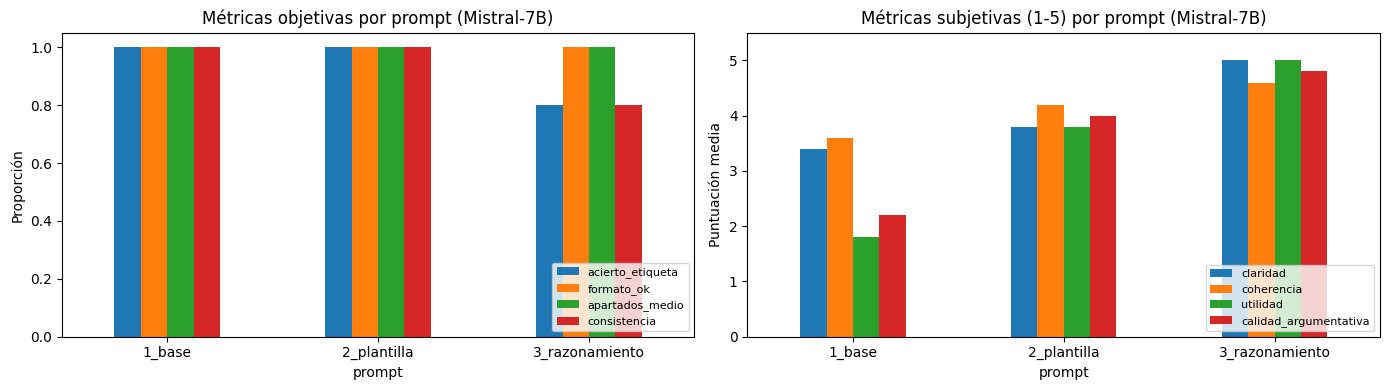

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

tabla_final[["acierto_etiqueta", "formato_ok", "apartados_medio", "consistencia"]].plot(
    kind="bar", ax=axes[0], rot=0
)
axes[0].set_title("Métricas objetivas por prompt (Mistral-7B)")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Proporción")
axes[0].legend(loc="lower right", fontsize=8)

tabla_final[["claridad", "coherencia", "utilidad", "calidad_argumentativa"]].plot(
    kind="bar", ax=axes[1], rot=0
)
axes[1].set_title("Métricas subjetivas (1-5) por prompt (Mistral-7B)")
axes[1].set_ylim(0, 5.5)
axes[1].set_ylabel("Puntuación media")
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()


---
## 🔁 8. Análisis de variabilidad

Más allá de la consistencia de la etiqueta, observamos la longitud de las respuestas y su dispersión.


In [ ]:
df_resultados["longitud_chars"] = df_resultados["respuesta"].str.len()
df_resultados["longitud_palabras"] = df_resultados["respuesta"].str.split().str.len()

variabilidad = (
    df_resultados.groupby("prompt")
      .agg(
          long_media_chars=("longitud_chars", "mean"),
          long_std_chars=("longitud_chars", "std"),
          long_media_palabras=("longitud_palabras", "mean"),
          long_std_palabras=("longitud_palabras", "std"),
          etiquetas_distintas=("etiqueta_predicha", lambda s: s.nunique()),
      )
      .round(1)
)
variabilidad


,long_media_chars,long_std_chars,long_media_palabras,long_std_palabras,etiquetas_distintas
prompt,,,,,
1_base,212.0,63.7,34.4,9.2,1
2_plantilla,174.0,26.1,25.8,4.8,1
3_razonamiento,822.4,185.7,130.0,30.7,2


In [ ]:
# Tabla de etiquetas por repetición -> de un vistazo se ve qué prompt es más estable
pd.crosstab(df_resultados["prompt"], df_resultados["etiqueta_predicha"], dropna=False)


etiqueta_predicha,negativa,positiva
prompt,,
1_base,5,0
2_plantilla,5,0
3_razonamiento,4,1


---
## 💾 9. Exportar resultados a CSV


In [ ]:
import os

output_path_resultados = "resultados_mistral7b_instruct.csv"
output_path_resumen = "resumen_mistral7b_instruct.csv"

df_resultados.to_csv(output_path_resultados, index=False, encoding="utf-8-sig")
tabla_final.to_csv(output_path_resumen, encoding="utf-8-sig")

print(f"✅ Resultados detallados : {os.path.abspath(output_path_resultados)}")
print(f"✅ Resumen por prompt    : {os.path.abspath(output_path_resumen)}")

try:
    from google.colab import files
    files.download(output_path_resultados)
    files.download(output_path_resumen)
except ImportError:
    print("\n(Ejecutándose en local: los CSVs se han guardado junto al notebook.)")

✅ Resultados detallados : /content/resultados_mistral7b_instruct.csv
✅ Resumen por prompt    : /content/resumen_mistral7b_instruct.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 🧩 10. Conclusiones (rellenar tras la ejecución)

> Esta sección debe redactarse **después** de ejecutar el notebook, mirando los resultados reales obtenidos en la sesión que entreguéis.

Ideas que conviene incluir:

- **Acierto de etiqueta:** ¿Los tres prompts aciertan la etiqueta `negativa`? ¿En cuál acierta más veces sobre las 5 repeticiones?
- **Formato:** ¿Mistral-7B respeta el formato pedido en el prompt 2 (`Clasificación:` / `Justificación:`)? ¿Y los apartados del prompt 3?
- **Estabilidad:** ¿El prompt estructurado reduce la variabilidad respecto al prompt base? Comparar la columna `consistencia` y la `crosstab`.
- **Calidad argumentativa:** ¿El prompt de razonamiento mejora la justificación o solo la alarga?
- **Coste vs beneficio:** ¿Compensa el coste extra (más tokens, más tiempo) del prompt 3 frente al 2?
- **Comparación con el grupo:** ¿Mistral-7B rinde mejor o peor que Gemma 2 2B y Phi-3 en esta tarea?

---

### 📚 Referencia de prompts y ajustes

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| `do_sample` | `True` | Muestreo estocástico (necesario para variabilidad) |
| `temperature` | `0.7` | Aleatoriedad moderada (requisito del enunciado: > 0) |
| `top_p` | `0.9` | Nucleus sampling |
| `max_new_tokens` | 200–400 | Más para el prompt 3 (razonamiento extendido) |
| `load_in_4bit` | `True` | Cuantización 4-bit para caber en T4 de Colab |
| `bnb_4bit_quant_type` | `nf4` | Tipo de cuantización (NormalFloat4) |
| `bnb_4bit_compute_dtype` | `bfloat16` | Tipo de cómputo en BF16 |
| `repeticiones` | 5 por prompt | Para estimar consistencia |

**Comparación con el resto del grupo** (se hará en la presentación común): tabla con acierto, formato, consistencia y calidad media por (modelo × prompt).
